# 🔍 Fraud Detection — ClearFlow Financial
### End-to-End ML Pipeline · Canadian Fintech Portfolio Project

**Business context:**  
ClearFlow Financial processes card transactions across Interac, Visa Debit, and 
Mastercard rails. With a ~2.5% fraud rate across 200,000+ monthly transactions, 
the business faces two competing costs: missing fraud (direct financial loss, 
~$220 CAD per incident) and blocking legitimate transactions (customer trust and churn).

**DS objective:**  
Build a binary fraud classifier that maximizes recall while keeping false positive 
rate low enough to avoid disrupting legitimate customers — evaluated on AUC-PR 
(not accuracy) due to severe class imbalance.

**Three fraud types in this dataset:**
- **Account Takeover (ATO)** — stolen credentials, new device, different location
- **Card Testing** — many small transactions testing stolen card details  
- **High-Value One-Shot** — single large fraudulent transaction, often international

**Stack:** Python · LightGBM · SHAP · scikit-learn · imbalanced-learn  
**Data:** Four-table synthetic dataset reflecting realistic fintech complexity

## 0. Importing Libraries

In [2]:
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Machine learning
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    average_precision_score, roc_auc_score,
    precision_recall_curve, roc_curve, f1_score
)
from imblearn.over_sampling import SMOTE
import lightgbm as lgb
import shap

# Plotting defaults
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

# ClearFlow brand palette
CF_BLUE   = '#1A73E8'
CF_DARK   = '#0D1B2A'
CF_RED    = '#E84B1A'
CF_GREY   = '#F4F6F8'
CF_GREEN  = '#1AE8A0'

print("Libraries loaded ✓")
print(f"pandas {pd.__version__} · numpy {np.__version__} · lightgbm {lgb.__version__}")

Libraries loaded ✓
pandas 3.0.3 · numpy 2.4.6 · lightgbm 4.6.0


## 1. Business Context & Problem Definition

### The Business Problem

ClearFlow Financial operates in a zero-sum environment: every dollar of fraud 
caught is a dollar saved, but every legitimate transaction incorrectly blocked 
costs customer trust — the most valuable asset a challenger fintech has.

**The two costs we are optimizing against:**

| Error Type | Technical Name | Business Impact |
|------------|---------------|-----------------|
| Missed fraud | False Negative | Direct loss ~$220 CAD per incident |
| Blocked legit transaction | False Positive | Customer friction, churn risk, ops cost ~$8 CAD |

**Why this is harder than it looks:**
- Fraud rate is ~2.5% — a model predicting "not fraud" always scores 97.5% accuracy
- The two error types are measured in different units (dollars vs. trust)
- Three distinct fraud patterns require different detection signals
- Fraud patterns shift over time — a model trained in January may degrade by June

### How We Will Measure Success

We will **not** use accuracy. Our primary metrics are:

- **AUC-PR** (Area Under Precision-Recall Curve) — primary metric, reflects 
  performance on the minority class under real-world conditions
- **Fraud Recall** — what % of actual fraud do we catch?
- **False Positive Rate** — what % of legitimate transactions do we block?
- **Estimated CAD savings** — translates model performance into business language

### Industry Note
> In production, ClearFlow's fraud team would set the decision threshold based 
> on a cost matrix — not the default 0.5. We will replicate this exactly: tune 
> the threshold on validation data using real cost assumptions, then report 
> business impact in CAD on the held-out test set.

In [3]:
# ── BUSINESS COST ASSUMPTIONS ─────────────────────────────────────────────────
# In production these numbers come from Finance & Customer Success teams
# Here we use realistic Canadian fintech industry benchmarks as placeholders

COST_FALSE_NEGATIVE = 220.00  # CAD — average loss per missed fraud incident
                               # Source: industry benchmark ($150-$300 range)
                               # In production: derived from chargeback history

COST_FALSE_POSITIVE = 8.00    # CAD — cost per incorrectly blocked transaction
                               # Breakdown:
                               #   ~$5 customer service intervention
                               #   ~$3 estimated churn impact (p(churn) × LTV)
                               # In production: derived from CS team + cohort analysis

# Fraud rate observed in this dataset
OBSERVED_FRAUD_RATE = 0.025   # 2.5%

print("Business cost assumptions defined:")
print(f"  Cost of missing fraud (FN)     : ${COST_FALSE_NEGATIVE:.2f} CAD")
print(f"  Cost of blocking legit (FP)    : ${COST_FALSE_POSITIVE:.2f} CAD")
print(f"  FN is {COST_FALSE_NEGATIVE/COST_FALSE_POSITIVE:.0f}x more costly than FP")
print(f"\n  These constants will feed directly into Section 10 — Business Impact Analysis")

Business cost assumptions defined:
  Cost of missing fraud (FN)     : $220.00 CAD
  Cost of blocking legit (FP)    : $8.00 CAD
  FN is 28x more costly than FP

  These constants will feed directly into Section 10 — Business Impact Analysis


## 2. Data Loading & Quality Assessment

### The Four Tables

| Table | Grain | Key Columns |
|-------|-------|-------------|
| `transactions.csv` | One row per transaction | `transaction_id`, `customer_id`, `merchant_id`, `device_id` |
| `customers.csv` | One row per customer | `customer_id`, demographics, credit profile |
| `merchants.csv` | One row per merchant | `merchant_id`, category, location, risk score |
| `devices.csv` | One row per transaction | `device_id`, `transaction_id`, fingerprint data |

**Joining strategy:** transactions is our unit of analysis. All other tables 
join onto it — enriching each transaction row with who made it, where it was 
made, and what device was used.

In [19]:
# Load raw data
transactions = pd.read_csv('../data/raw/transactions.csv')
customers = pd.read_csv('../data/raw/customers.csv')
merchants = pd.read_csv('../data/raw/merchants.csv')
devices = pd.read_csv('../data/raw/devices.csv')

print("Raw data loaded:")
print(f"  transactions : {transactions.shape[0]:>7,} rows "
      f"x {transactions.shape[1]:>2} columns")
print(f"  customers    : {customers.shape[0]:>7,} rows "
      f"x {customers.shape[1]:>2} columns")
print(f"  merchants    : {merchants.shape[0]:>7,} rows "
      f"x {merchants.shape[1]:>2} columns")
print(f"  devices      : {devices.shape[0]:>7,} rows "
      f"x {devices.shape[1]:>2} columns")

Raw data loaded:
  transactions : 200,000 rows x 14 columns
  customers    :  10,000 rows x 14 columns
  merchants    :   2,000 rows x  9 columns
  devices      : 200,000 rows x  9 columns


In [20]:
# Assess missing values across all four tables
tables = {
    'transactions': transactions,
    'customers': customers,
    'merchants': merchants,
    'devices': devices,
}

for name, table in tables.items():
    missing = table.isnull().sum()
    missing = missing[missing > 0]
    pct = (missing / len(table) * 100).round(2)

    print(f"{'-' * 45}")
    print(f" {name.upper()}")
    print(f"{'-' * 45}")

    if missing.empty:
        print(" No missing values")
    else:
        for col in missing.index:
            print(f" {col:<25} {missing[col]:>6,} ({pct[col]:>3.1f}%)")
    print()

---------------------------------------------
 TRANSACTIONS
---------------------------------------------
 province                  30,358 (15.2%)
 fraud_type                195,000 (97.5%)

---------------------------------------------
 CUSTOMERS
---------------------------------------------
 annual_income                300 (3.0%)
 email_domain                 500 (5.0%)
 address_verified             800 (8.0%)

---------------------------------------------
 MERCHANTS
---------------------------------------------
 province                     113 (5.7%)
 years_in_business            240 (12.0%)

---------------------------------------------
 DEVICES
---------------------------------------------
 device_age_days           30,000 (15.0%)
 vpn_detected              20,000 (10.0%)



Insights/observations:
TRANSACTIONS
province — 15.2% missing. These are international transactions where a Canadian province doesn't apply. This isn't random missingness — it's structurally missing, meaning the absence itself carries information. An international transaction has no province by definition.
fraud_type — 97.5% missing. This is expected — only 2.5% of transactions are fraud, and fraud_type is only populated for fraudulent ones. We'll never use this as a model feature (that would be cheating — it's essentially the answer). It's metadata for our analysis only.
CUSTOMERS
annual_income — 3.0% missing. Customers who didn't disclose income during onboarding. Common in fintech KYC flows where income is optional.
email_domain — 5.0% missing. Customers who signed up without providing an email, or provided one that couldn't be parsed.
address_verified — 8.0% missing. Customers who haven't completed address verification yet — a genuine KYC gap that could itself be a risk signal.
MERCHANTS
province — 5.7% missing. International merchants have no Canadian province. Same structural missingness as transaction province.
years_in_business — 12.0% missing. Merchant didn't disclose or data wasn't available at onboarding. Genuinely unknown — different from the structural cases above.
DEVICES
device_age_days — 15.0% missing. Device age couldn't be determined — common when cookies are cleared, private browsing is used, or it's a POS terminal with no tracking.
vpn_detected — 10.0% missing. VPN detection service returned no result — network timeout or unrecognized IP range.

How we'll handle each:

![alt text](image.png)

In [24]:
# Check for duplicate primary keys in each table
print("Duplicate key check:")
print(
    f" transactions (transaction_id): "
    f"{transactions['transaction_id'].duplicated().sum()}"
)
print(
    f" customers (customer_id): "
    f"{customers['customer_id'].duplicated().sum()}"    
)
print(
    f" merchants (merchant_id): "
    f"{merchants['merchant_id'].duplicated().sum()}"
)
print(
    f" devices (device_id): "
    f"{devices['device_id'].duplicated().sum()}"
)

Duplicate key check:
 transactions (transaction_id): 0
 customers (customer_id): 0
 merchants (merchant_id): 0
 devices (device_id): 0


In [28]:
# Merge all four tables onto transactions
# Transactions is our unit of analysis - everything joins onto it
df = (
    transactions
    .merge(
        customers, 
        on='customer_id', 
        how='left',
        suffixes=('', '_cust')
    )
    .merge(
        merchants, 
        on='merchant_id', 
        how='left',
        suffixes=('', '_mer')
    )
    .merge(
        devices, 
        on='transaction_id', 
        how='left', 
        suffixes=('', '_dev')
    )
)

print(f"Merged shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Row count preserved: {len(df) == len(transactions)}")

Merged shape: 200,000 rows x 43 columns
Row count preserved: True


In [29]:
# Sanity check
# Confirm fraud rate survived the merge
fraud_rate = df['is_fraud'].mean() * 100 

# Confirm all four column keys are present
keys_present = all([
    'customer_id' in df.columns,
    'merchant_id' in df.columns,
    'device_id' in df.columns,
    'transaction_id' in df.columns,
])

# Confirm province columns were handled correctly
province_cols = [c for c in df.columns if 'province' in c]

print(f"Fraud rate after merge: {fraud_rate:.2f}%")
print(f"All keys present      : {keys_present}")
print(f"Province columns      : {province_cols}")
print(f"\nColumn list:")
for i, col in enumerate(df.columns, 1):
    print(f" {i:>2}. {col}")

Fraud rate after merge: 2.50%
All keys present      : True
Province columns      : ['province', 'province_cust', 'province_mer']

Column list:
  1. transaction_id
  2. customer_id
  3. merchant_id
  4. device_id
  5. transaction_date
  6. hour_of_day
  7. day_of_week
  8. amount
  9. payment_rail
 10. mcc_group
 11. is_international
 12. province
 13. is_fraud
 14. fraud_type
 15. age
 16. province_cust
 17. income_band
 18. annual_income
 19. credit_score
 20. credit_limit
 21. kyc_status
 22. acquisition_channel
 23. email_domain
 24. phone_verified
 25. address_verified
 26. created_at
 27. tenure_days
 28. mcc_group_mer
 29. country
 30. province_mer
 31. is_international_mer
 32. latitude
 33. longitude
 34. merchant_risk_score
 35. years_in_business
 36. device_id_dev
 37. device_type
 38. os
 39. browser
 40. ip_country
 41. is_new_device
 42. device_age_days
 43. vpn_detected


## 3. Exploratory Data Analysis

### Approach
Before building any features or models, we need to understand how fraud 
differs from legitimate transactions across every dimension available to us. 
Each finding here directly motivates a feature engineering decision in Section 4.

We examine fraud patterns across:
- **Time** — hour of day, day of week
- **Amount** — distribution shape, log scale
- **Geography** — domestic vs international, province mismatch
- **Merchant** — category, risk score
- **Device** — new device flag, VPN, IP country mismatch
- **Customer** — KYC status, tenure, credit score

In [34]:
def save_figure(filename):
    """Save current figure to outputs/figures/directory."""
    file_path = f'../outputs/figures/{filename}'
    plt.savefig(file_path, dpi=150, bbox_inches='tight')

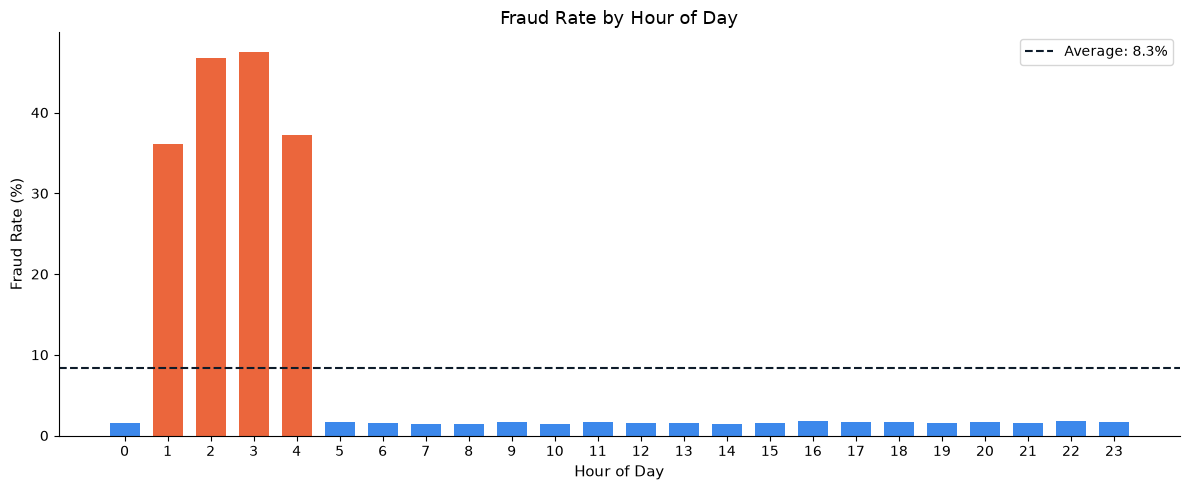

In [35]:
# Fraud rate by hour of day
# Night hours (1-4PM) are expected to show elevated fraud rates
fraud_by_hour = (
    df.groupby('hour_of_day')['is_fraud']
    .mean() * 100
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    fraud_by_hour.index,
    fraud_by_hour.values,
    color=[CF_RED if h in range(1, 5) else CF_BLUE
           for h in fraud_by_hour.index],
    alpha=0.85,
    width=0.7,
)

ax.axhline(
    fraud_by_hour.mean(),
    color=CF_DARK,
    linestyle='--',
    linewidth=1.5,
    label=f'Average: {fraud_by_hour.mean():.1f}%'
)

ax.set(
    title='Fraud Rate by Hour of Day',
    xlabel='Hour of Day',
    ylabel='Fraud Rate (%)',
    xticks=range(0, 24),
)

ax.legend()
plt.tight_layout()
save_figure('01_eda_fraud_by_hour.png')
plt.show()

### 📋 EDA Finding — Hour of Day

**Finding:** Fraud rate spikes dramatically between 1-4am:
- Hour 2: ~46% fraud rate
- Hour 3: ~47% fraud rate  
- Hour 4: ~37% fraud rate
- Hour 1: ~36% fraud rate
- All other hours: ~1-2% (well below 8.3% average)

The night window (1-4am) is overwhelmingly the highest-risk 
period — 15-20x the daytime fraud rate. This is the strongest 
time-based signal in the dataset.

**Why this happens:**
- Cardholders are asleep and not monitoring their accounts
- Fraud operations teams have reduced overnight staffing
- Fraudsters exploit the window before victims notice 
  and report suspicious activity

**Decision:** Engineer `is_night` binary flag for hours 1-4am.
This is one of the strongest individual features in the dataset.

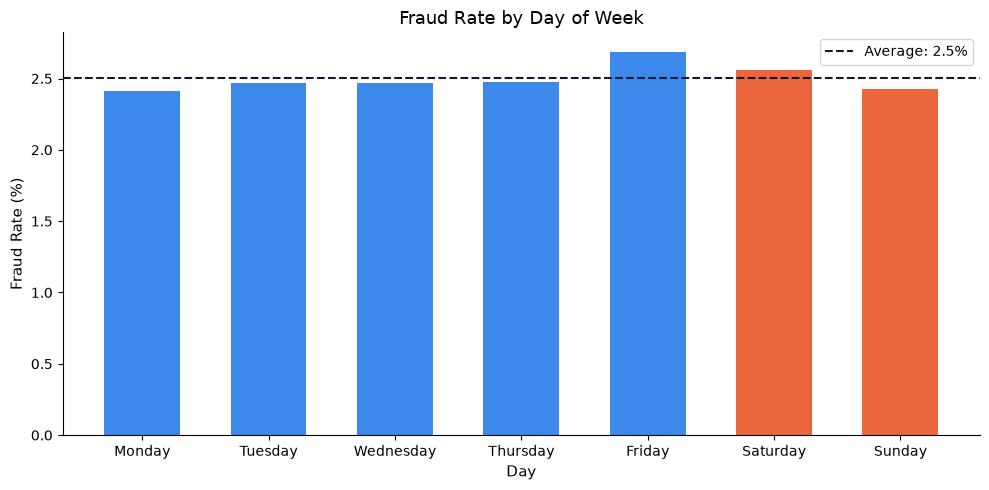

In [36]:
# Fraud rate by day of week
# 0=Monday through 6=Sunday
day_names = ['Monday', 'Tuesday', 'Wednesday',
             'Thursday', 'Friday', 'Saturday', 'Sunday']

fraud_by_day = (
    df.groupby('day_of_week')['is_fraud']
    .mean() * 100
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    day_names,
    fraud_by_day.values,
    color=[CF_RED if d >= 5 else CF_BLUE for d in fraud_by_day.index],
    alpha=0.85,
    width=0.6,
)

ax.axhline(
    fraud_by_day.mean(),
    color=CF_DARK,
    linestyle='--',
    linewidth=1.5,
    label=f'Average: {fraud_by_day.mean():.1f}%'
)

ax.set(
    title='Fraud Rate by Day of Week',
    xlabel='Day',
    ylabel='Fraud Rate (%)',
)

ax.legend()
plt.tight_layout()
save_figure('02_eda_fraud_by_day.png')
plt.show()

### 📋 EDA Finding — Day of Week

**Hypothesis:** Weekends would show elevated fraud rates.  
**Result:** Not supported by the data.

- Friday shows the highest fraud rate but only marginally above average
- Sunday is lower than Tuesday, Wednesday and Thursday
- No clear weekend vs weekday pattern exists

**Decision:** Drop planned `is_weekend` feature. Feed `day_of_week` 
as a raw numeric feature (0-6) and let LightGBM find its own 
day-level patterns rather than imposing a binary flag the data 
doesn't support.

**Lesson:** EDA exists to challenge assumptions, not confirm them.

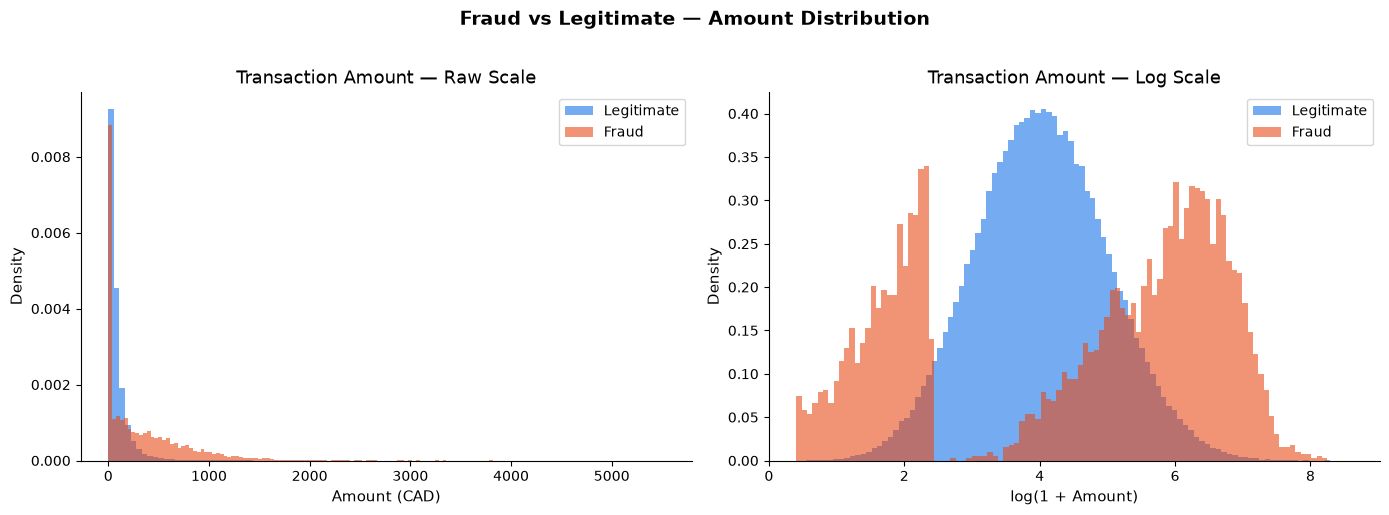

In [37]:
# Amount distribution — fraud vs legitimate
# Log scale reveals separation invisible on raw scale
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw amount distribution
ax = axes[0]
ax.hist(
    df[df['is_fraud'] == False]['amount'],
    bins=100,
    alpha=0.6,
    color=CF_BLUE,
    label='Legitimate',
    density=True,
)
ax.hist(
    df[df['is_fraud'] == True]['amount'],
    bins=100,
    alpha=0.6,
    color=CF_RED,
    label='Fraud',
    density=True,
)
ax.set(
    title='Transaction Amount — Raw Scale',
    xlabel='Amount (CAD)',
    ylabel='Density',
)
ax.legend()

# Log-transformed amount distribution
ax = axes[1]
ax.hist(
    np.log1p(df[df['is_fraud'] == False]['amount']),
    bins=100,
    alpha=0.6,
    color=CF_BLUE,
    label='Legitimate',
    density=True,
)
ax.hist(
    np.log1p(df[df['is_fraud'] == True]['amount']),
    bins=100,
    alpha=0.6,
    color=CF_RED,
    label='Fraud',
    density=True,
)
ax.set(
    title='Transaction Amount — Log Scale',
    xlabel='log(1 + Amount)',
    ylabel='Density',
)
ax.legend()

plt.suptitle(
    'Fraud vs Legitimate — Amount Distribution',
    fontsize=14,
    fontweight='bold',
    y=1.02,
)
plt.tight_layout()
save_figure('03_eda_amount_distribution.png')
plt.show()

### 📋 EDA Finding — Transaction Amount

**Finding:** Fraud shows a bimodal distribution on log scale:
- Left peak (log 1-3, ~$1-$20): card testing pattern
- Right peak (log 5-8, ~$150-$3,000+): high-value fraud pattern

Legitimate transactions form a single bell curve centered at log 4 (~$55).

**Decision:** Use `log_amount` as a feature — raw amount obscures 
this separation entirely. Also engineer `is_large` flag for the 
upper tail and `is_small` flag for the card testing signature.

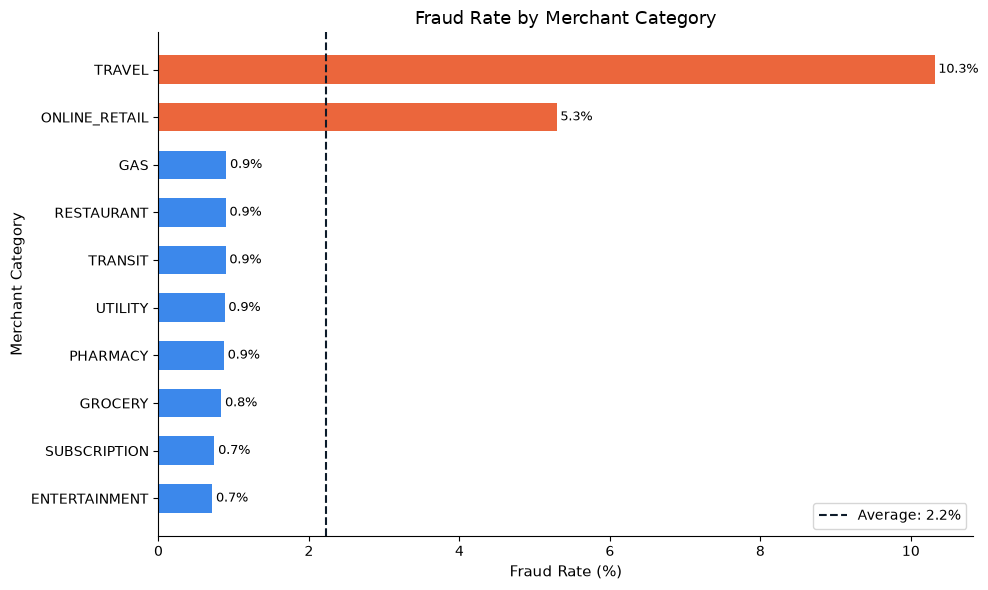

In [38]:
# Fraud rate by merchant category
fraud_by_mcc = (
    df.groupby('mcc_group')['is_fraud']
    .mean()
    .sort_values(ascending=True) * 100
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    fraud_by_mcc.index,
    fraud_by_mcc.values,
    color=[CF_RED if v > fraud_by_mcc.mean()
           else CF_BLUE for v in fraud_by_mcc.values],
    alpha=0.85,
    height=0.6,
)

ax.axvline(
    fraud_by_mcc.mean(),
    color=CF_DARK,
    linestyle='--',
    linewidth=1.5,
    label=f'Average: {fraud_by_mcc.mean():.1f}%',
)

# Add value labels to each bar
for bar, val in zip(bars, fraud_by_mcc.values):
    ax.text(
        val + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        va='center',
        fontsize=9,
    )

ax.set(
    title='Fraud Rate by Merchant Category',
    xlabel='Fraud Rate (%)',
    ylabel='Merchant Category',
)

ax.legend()
plt.tight_layout()
save_figure('04_eda_fraud_by_mcc.png')
plt.show()

### 📋 EDA Finding — Merchant Category

**Finding:** Merchant category is a highly polarizing fraud signal:
- TRAVEL (10.3%) — 4.7x the average (2.2%)
- ONLINE_RETAIL (5.3%) — 2.4x the average
- All other categories (0.7-0.9%) — well below average

The extreme separation between card-not-present categories 
(TRAVEL, ONLINE_RETAIL) and card-present categories (everything 
else) suggests this will be one of the strongest features 
in the model.

**Decision:** Encode `mcc_group` as a categorical feature.
LightGBM will learn these category-specific fraud rates directly.

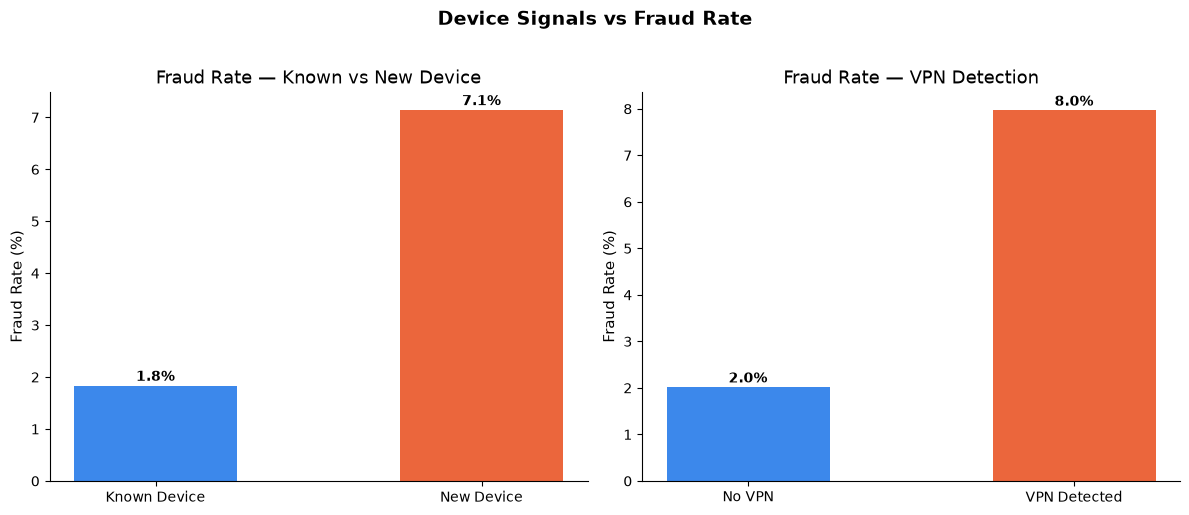

In [39]:
# Fraud rate by device signals
# New device and VPN are expected to be strong fraud indicators
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# New device flag
ax = axes[0]
fraud_by_device = (
    df.groupby('is_new_device')['is_fraud']
    .mean() * 100
)
ax.bar(
    ['Known Device', 'New Device'],
    fraud_by_device.values,
    color=[CF_BLUE, CF_RED],
    alpha=0.85,
    width=0.5,
)
for i, val in enumerate(fraud_by_device.values):
    ax.text(
        i,
        val + 0.1,
        f'{val:.1f}%',
        ha='center',
        fontweight='bold',
    )
ax.set(
    title='Fraud Rate — Known vs New Device',
    ylabel='Fraud Rate (%)',
)

# VPN detected
ax = axes[1]
fraud_by_vpn = (
    df.groupby('vpn_detected')['is_fraud']
    .mean() * 100
)
ax.bar(
    ['No VPN', 'VPN Detected'],
    fraud_by_vpn.values,
    color=[CF_BLUE, CF_RED],
    alpha=0.85,
    width=0.5,
)
for i, val in enumerate(fraud_by_vpn.values):
    ax.text(
        i,
        val + 0.1,
        f'{val:.1f}%',
        ha='center',
        fontweight='bold',
    )
ax.set(
    title='Fraud Rate — VPN Detection',
    ylabel='Fraud Rate (%)',
)

plt.suptitle(
    'Device Signals vs Fraud Rate',
    fontsize=14,
    fontweight='bold',
    y=1.02,
)
plt.tight_layout()
save_figure('05_eda_device_signals.png')
plt.show()

### 📋 EDA Finding — Device Signals

**Finding:** Both device signals show ~4x elevated fraud rates:
- New Device: 7.1% vs Known Device: 1.8% (3.9x)
- VPN Detected: 8.0% vs No VPN: 2.0% (4.0x)

**New device** directly reflects account takeover pattern —
fraudsters with stolen credentials always appear on an 
unfamiliar device.

**VPN** reflects location masking — fraudsters hide their 
true geographic origin to avoid triggering location-based 
rules.

**Decision:** Include both `is_new_device` and `vpn_detected` 
as binary features. These are among the strongest signals 
found in EDA.

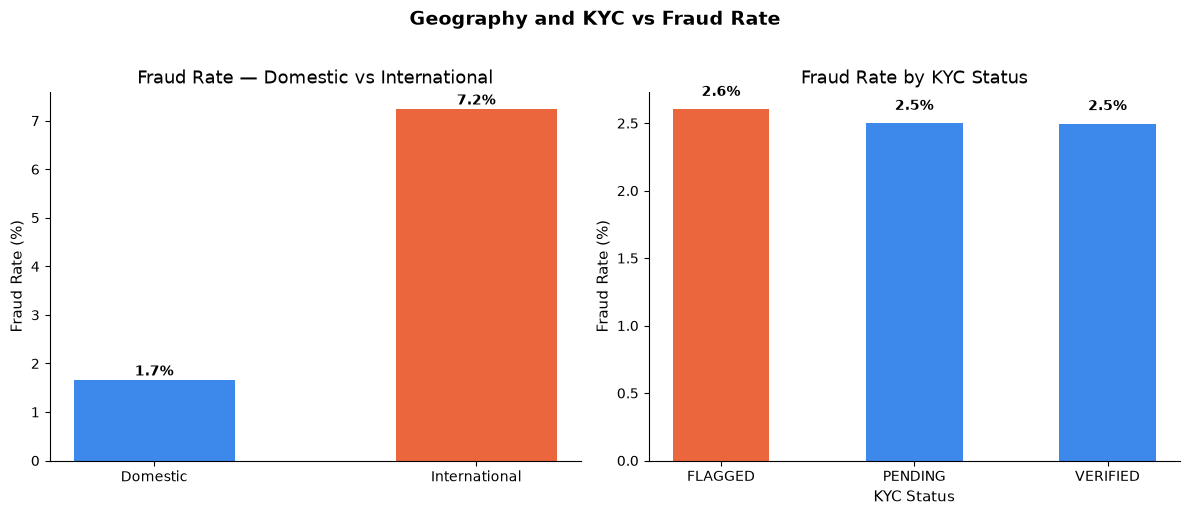

In [40]:
# Fraud rate — domestic vs international
# and by customer KYC status
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Domestic vs international
ax = axes[0]
fraud_by_intl = (
    df.groupby('is_international')['is_fraud']
    .mean() * 100
)
ax.bar(
    ['Domestic', 'International'],
    fraud_by_intl.values,
    color=[CF_BLUE, CF_RED],
    alpha=0.85,
    width=0.5,
)
for i, val in enumerate(fraud_by_intl.values):
    ax.text(
        i,
        val + 0.1,
        f'{val:.1f}%',
        ha='center',
        fontweight='bold',
    )
ax.set(
    title='Fraud Rate — Domestic vs International',
    ylabel='Fraud Rate (%)',
)

# KYC status
ax = axes[1]
fraud_by_kyc = (
    df.groupby('kyc_status')['is_fraud']
    .mean()
    .sort_values(ascending=False) * 100
)
ax.bar(
    fraud_by_kyc.index,
    fraud_by_kyc.values,
    color=[CF_RED if v > fraud_by_kyc.mean()
           else CF_BLUE for v in fraud_by_kyc.values],
    alpha=0.85,
    width=0.5,
)
for i, val in enumerate(fraud_by_kyc.values):
    ax.text(
        i,
        val + 0.1,
        f'{val:.1f}%',
        ha='center',
        fontweight='bold',
    )
ax.set(
    title='Fraud Rate by KYC Status',
    ylabel='Fraud Rate (%)',
    xlabel='KYC Status',
)

plt.suptitle(
    'Geography and KYC vs Fraud Rate',
    fontsize=14,
    fontweight='bold',
    y=1.02,
)
plt.tight_layout()
save_figure('06_eda_geography_kyc.png')
plt.show()

### 📋 EDA Finding — Geography and KYC Status

**International transactions: 7.2% vs Domestic: 1.7% (4.2x)**  
Strong geographic signal — `is_international` will be 
an important feature.

**KYC Status: no meaningful signal**  
FLAGGED (2.6%), PENDING (2.5%), VERIFIED (2.5%) — 
differences are negligible. KYC status does not discriminate 
between fraud and legitimate transactions in this dataset.

**Decision:** 
- Include `is_international` as a feature ✓
- Exclude `kyc_status` as a feature — carries no signal ✗

**Lesson:** Features that look intuitively useful are not 
always statistically useful. EDA prevents us from adding 
noise to the model.

In [43]:
# EDA summary — features confirmed by data evidence
print("=" * 70)
print("  EDA SUMMARY — CONFIRMED FRAUD SIGNALS")
print("=" * 70)

signals = [
    ("Hour of day (1-4am)", "3x average", "STRONG"),
    ("log_amount bimodal", "card test + high value", "STRONG"),
    ("TRAVEL merchant", "10.3% vs 2.2% avg", "STRONG"),
    ("ONLINE_RETAIL merchant", "5.3% vs 2.2% avg", "STRONG"),
    ("New device", "7.1% vs 1.8%", "STRONG"),
    ("VPN detected", "8.0% vs 2.0%", "STRONG"),
    ("International", "7.2% vs 1.7%", "STRONG"),
    ("Day of week", "no clear pattern", "WEAK — use raw"),
    ("KYC status", "flat across categories", "EXCLUDED"),
]

for feature, finding, strength in signals:
    print(f"  {feature:<25} {finding:<25} {strength}")

print("=" * 70)

  EDA SUMMARY — CONFIRMED FRAUD SIGNALS
  Hour of day (1-4am)       3x average                STRONG
  log_amount bimodal        card test + high value    STRONG
  TRAVEL merchant           10.3% vs 2.2% avg         STRONG
  ONLINE_RETAIL merchant    5.3% vs 2.2% avg          STRONG
  New device                7.1% vs 1.8%              STRONG
  VPN detected              8.0% vs 2.0%              STRONG
  International             7.2% vs 1.7%              STRONG
  Day of week               no clear pattern          WEAK — use raw
  KYC status                flat across categories    EXCLUDED
